### Import Libraries

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
from keras import applications
from keras import optimizers
from keras._tf_keras.keras.models import Sequential
from keras._tf_keras.keras.layers import Activation, Dense, Dropout, Flatten
from keras._tf_keras.keras.utils import to_categorical
from keras._tf_keras.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, classification_report
from keras._tf_keras.keras.layers import Input, Lambda, Dense, Flatten,Conv2D,MaxPool2D
from keras._tf_keras.keras.models import Model
from keras._tf_keras.keras.layers import Conv2D, MaxPooling2D
import numpy as np
from glob import glob
from PIL import ImageTk, Image
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import glob
import cv2

### Data Acquisition

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train_path = '/content/drive/MyDrive/Dataset/'
test_path =  '/content/drive/MyDrive/Dataset/'

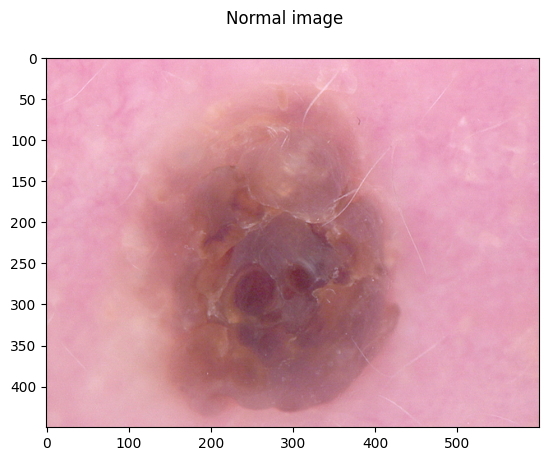

In [4]:
import glob
import matplotlib.image as mpimg
%matplotlib inline

normal_images = []
for img_path in glob.glob(train_path + '/NotMelanoma/*'):
    normal_images.append(mpimg.imread(img_path))

fig = plt.figure()
fig.suptitle('Normal image')
plt.imshow(normal_images[0], cmap='gray')



In [23]:
BASE_PATH = 'Dataset/NotMelanoma/'
hair_images =['ISIC_0024361','ISIC_0024403','ISIC_0024466','ISIC_0024467']

Reading image from: /content/drive/MyDrive/Dataset/NotMelanoma/ISIC_0024361.jpg
Reading image from: /content/drive/MyDrive/Dataset/NotMelanoma/ISIC_0024403.jpg
Reading image from: /content/drive/MyDrive/Dataset/NotMelanoma/ISIC_0024466.jpg
Reading image from: /content/drive/MyDrive/Dataset/NotMelanoma/ISIC_0024467.jpg


[]

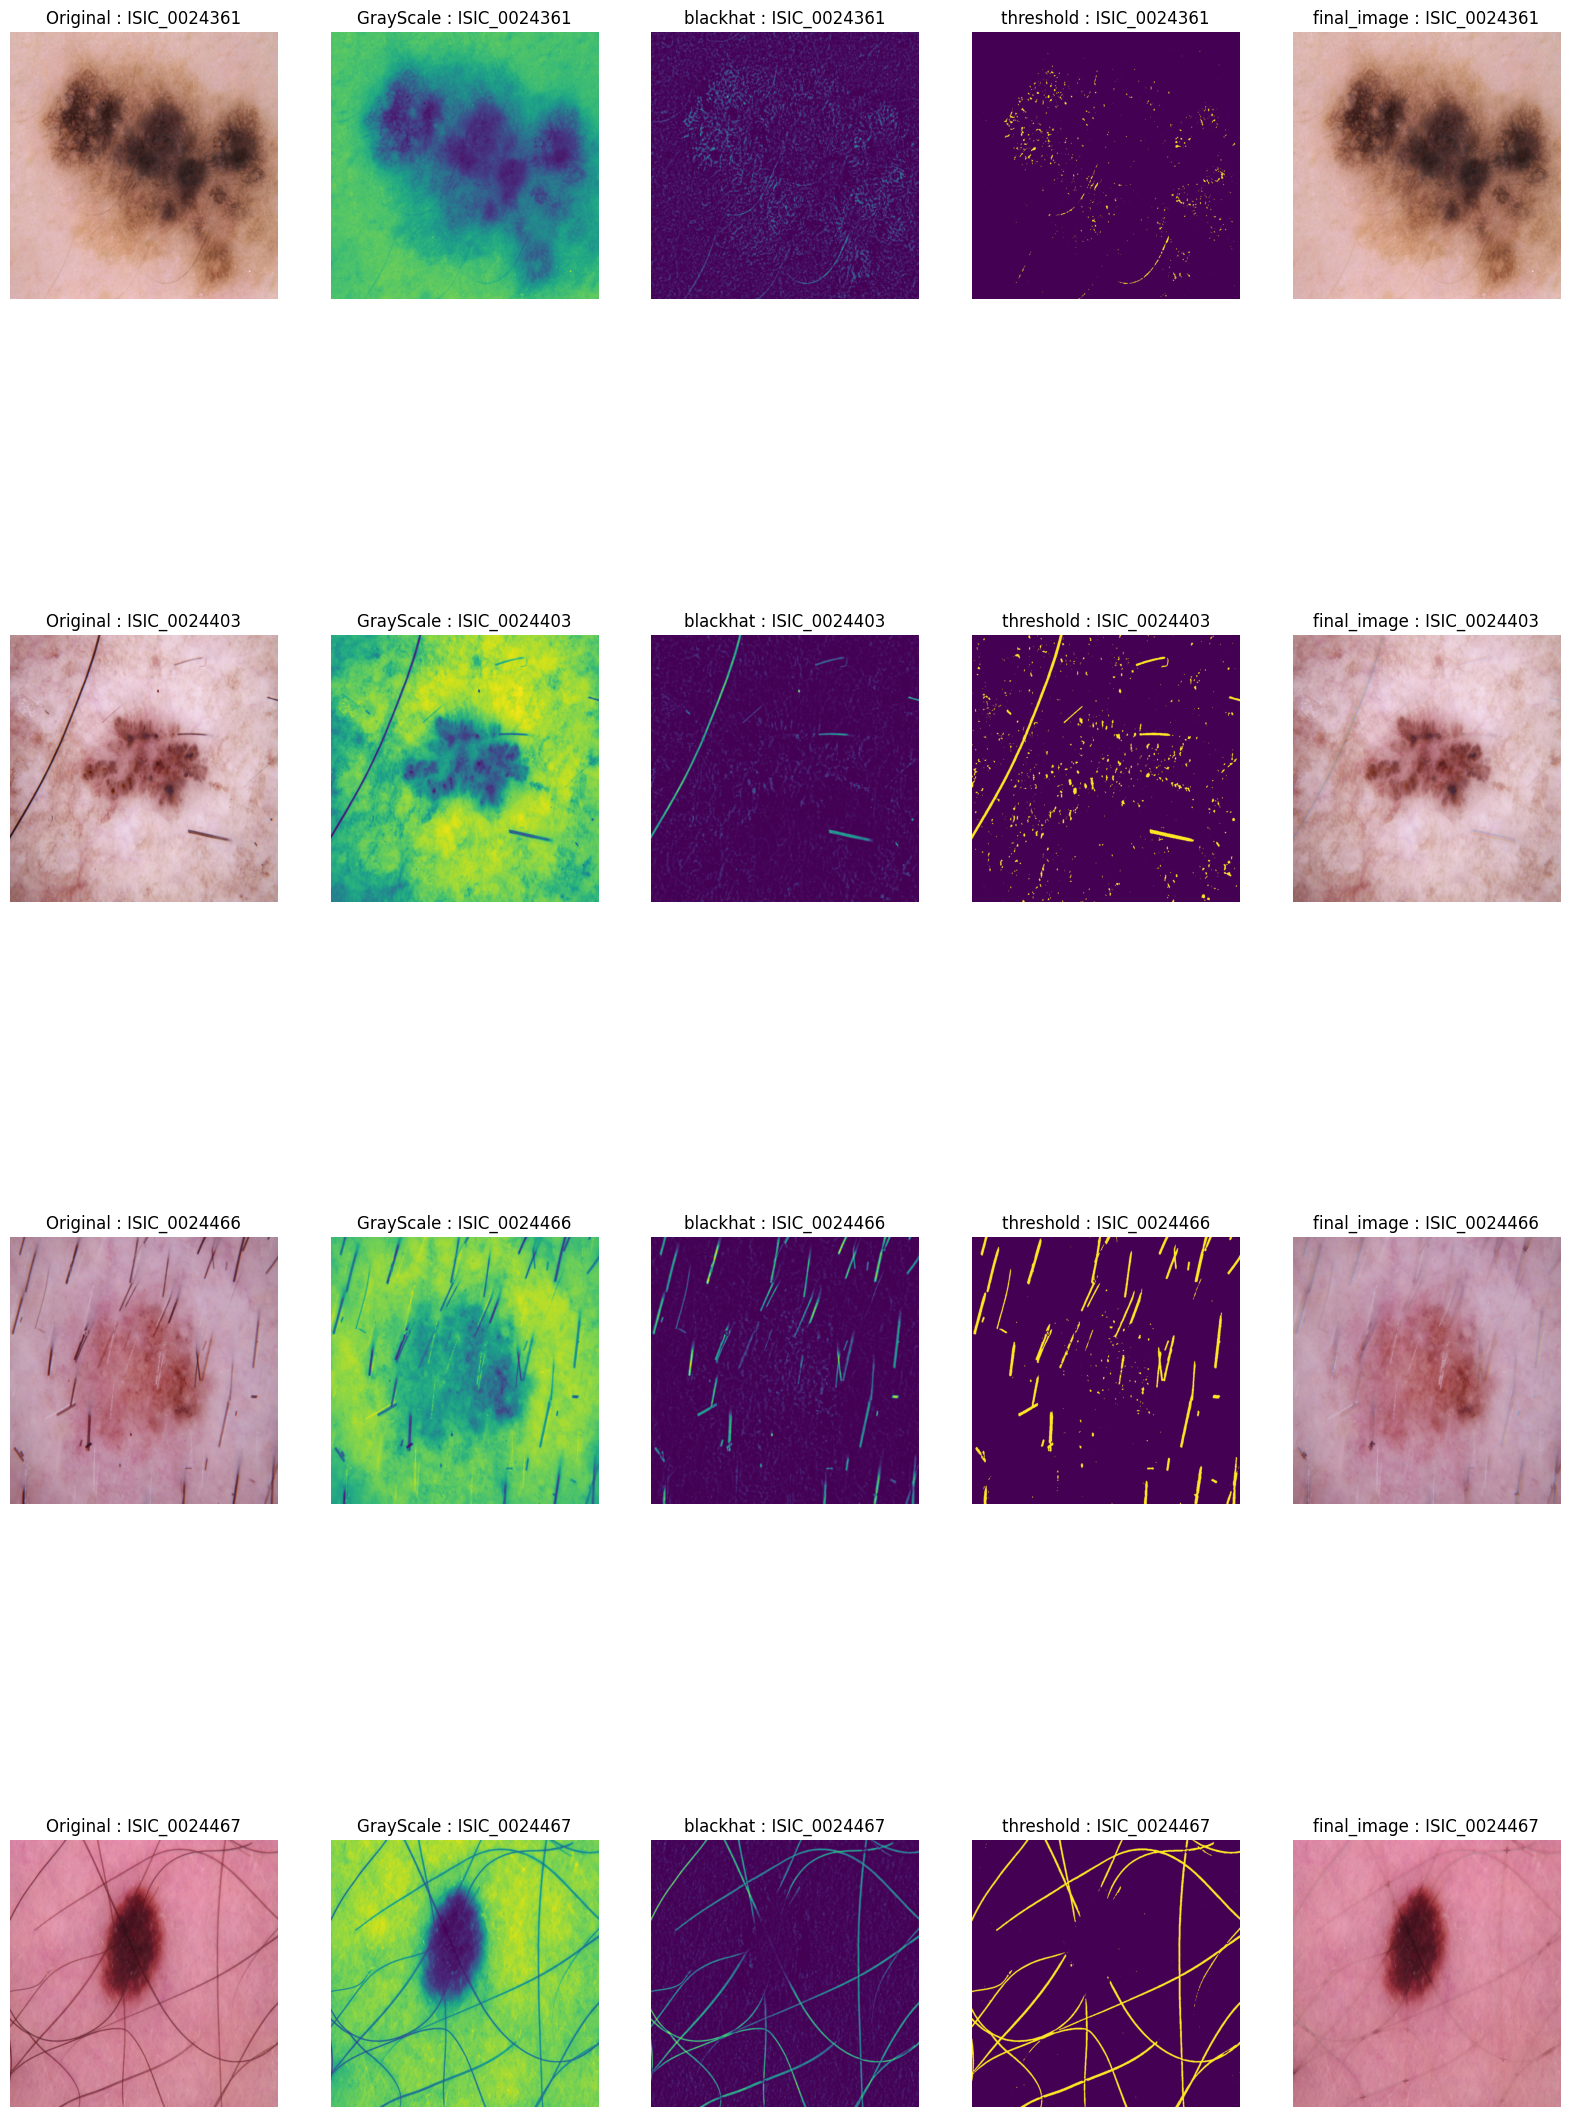

In [25]:
l = len(hair_images[:4])

fig = plt.figure(figsize=(20,30))

for i,image_name in enumerate(hair_images[:4]):
       # Updated path to include the train_path prefix
    image_path = os.path.join(train_path, 'NotMelanoma', image_name + '.jpg')

    # Print the image path to verify it's correct
    print(f"Reading image from: {image_path}")

    image = cv2.imread(image_path)

    # Check if image was loaded successfully
    if image is None:
        print(f"Error: Could not load image from {image_path}")
        continue  # Skip to the next image
    image_resize = cv2.resize(image,(1024,1024))
    plt.subplot(l, 5, (i*5)+1)
    # Convert the original image to grayscale
    plt.imshow(cv2.cvtColor(image_resize, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Original : '+ image_name)

    grayScale = cv2.cvtColor(image_resize, cv2.COLOR_RGB2GRAY)
    plt.subplot(l, 5, (i*5)+2)
    plt.imshow(grayScale)
    plt.axis('off')
    plt.title('GrayScale : '+ image_name)

    # Kernel for the morphological filtering
    kernel = cv2.getStructuringElement(1,(17,17))

    # Perform the blackHat filtering on the grayscale image to find the hair countours
    blackhat = cv2.morphologyEx(grayScale, cv2.MORPH_BLACKHAT, kernel)
    plt.subplot(l, 5, (i*5)+3)
    plt.imshow(blackhat)
    plt.axis('off')
    plt.title('blackhat : '+ image_name)

    # intensify the hair countours in preparation for the inpainting
    ret,threshold = cv2.threshold(blackhat,15,255,cv2.THRESH_BINARY)
    plt.subplot(l, 5, (i*5)+4)
    plt.imshow(threshold)
    plt.axis('off')
    plt.title('threshold : '+ image_name)

    # inpaint the original image depending on the mask
    final_image = cv2.inpaint(image_resize,threshold,3,cv2.INPAINT_TELEA)
    plt.subplot(l, 5, (i*5)+5)
    plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('final_image : '+ image_name)

plt.plot()

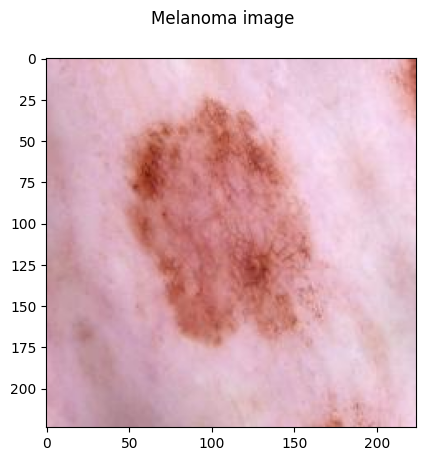

In [26]:
diesease_images = []
for img_path in glob.glob(train_path + '/Melanoma/*'):
    diesease_images.append(mpimg.imread(img_path))
fig = plt.figure()
fig.suptitle('Melanoma image')
plt.imshow(diesease_images[6], cmap='gray')

In [27]:
print('Number of Melanoma images: {}, Number of Normal images: {}'.format(len(diesease_images), len(normal_images)))

Number of Melanoma images: 3562, Number of Normal images: 3562


In [28]:
print(diesease_images[0].shape)

(224, 224, 3)


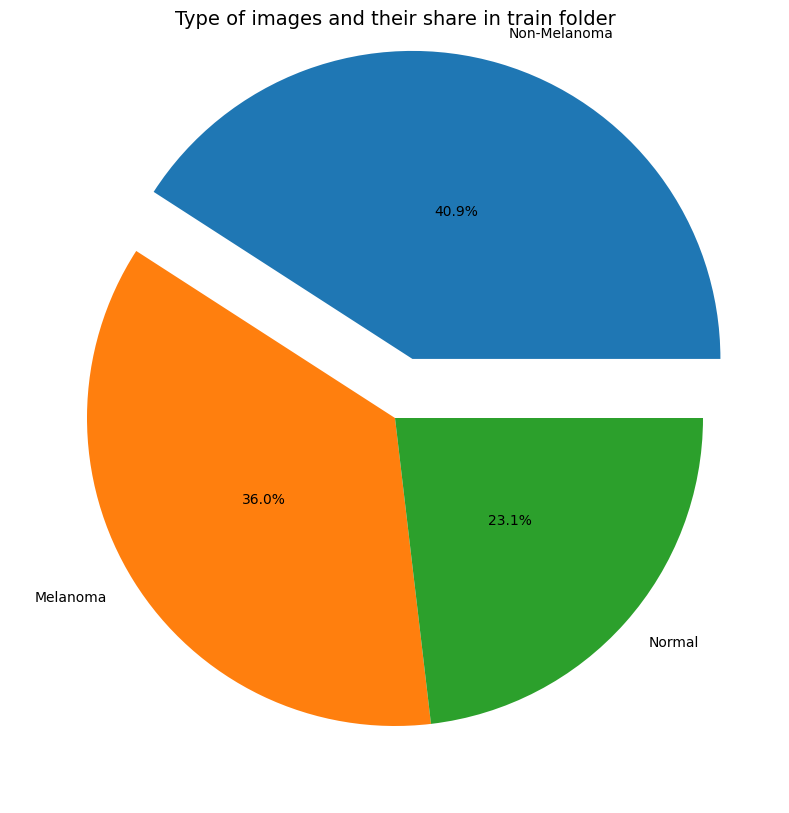

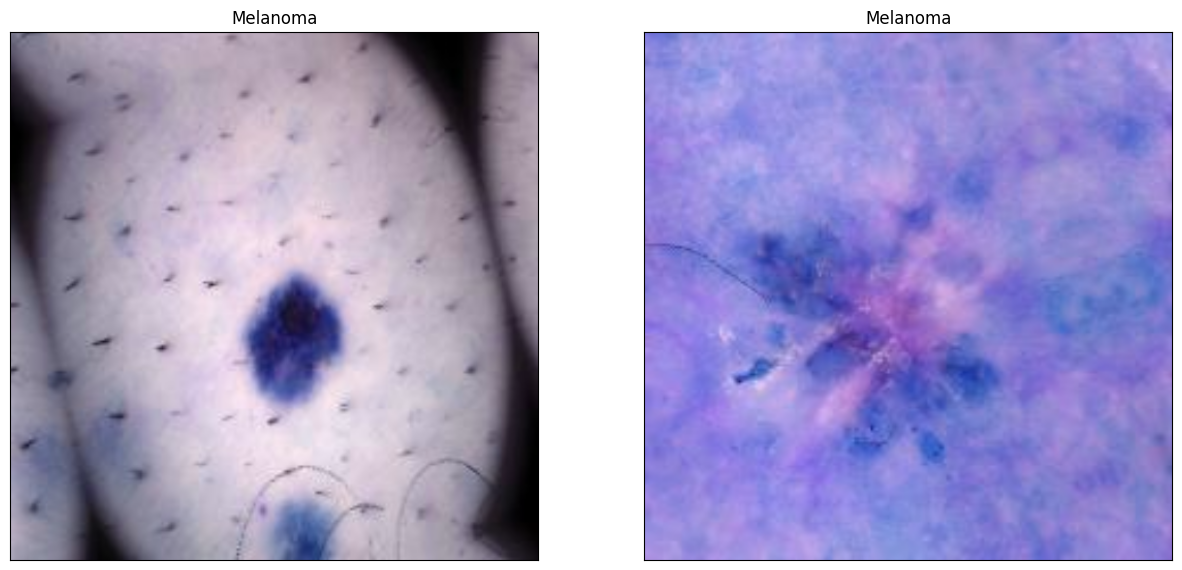

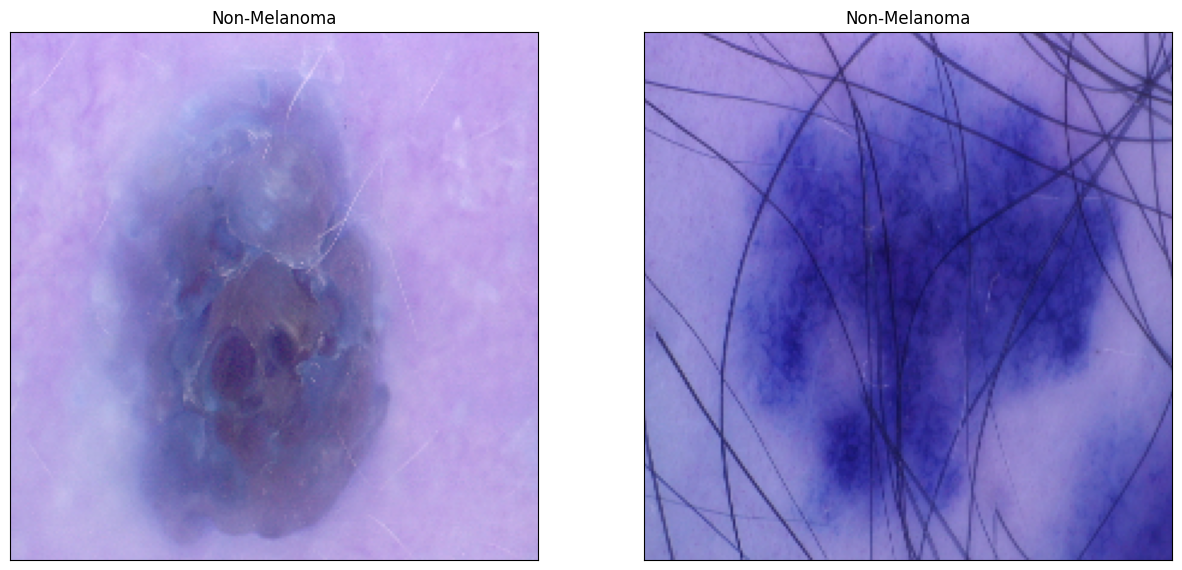

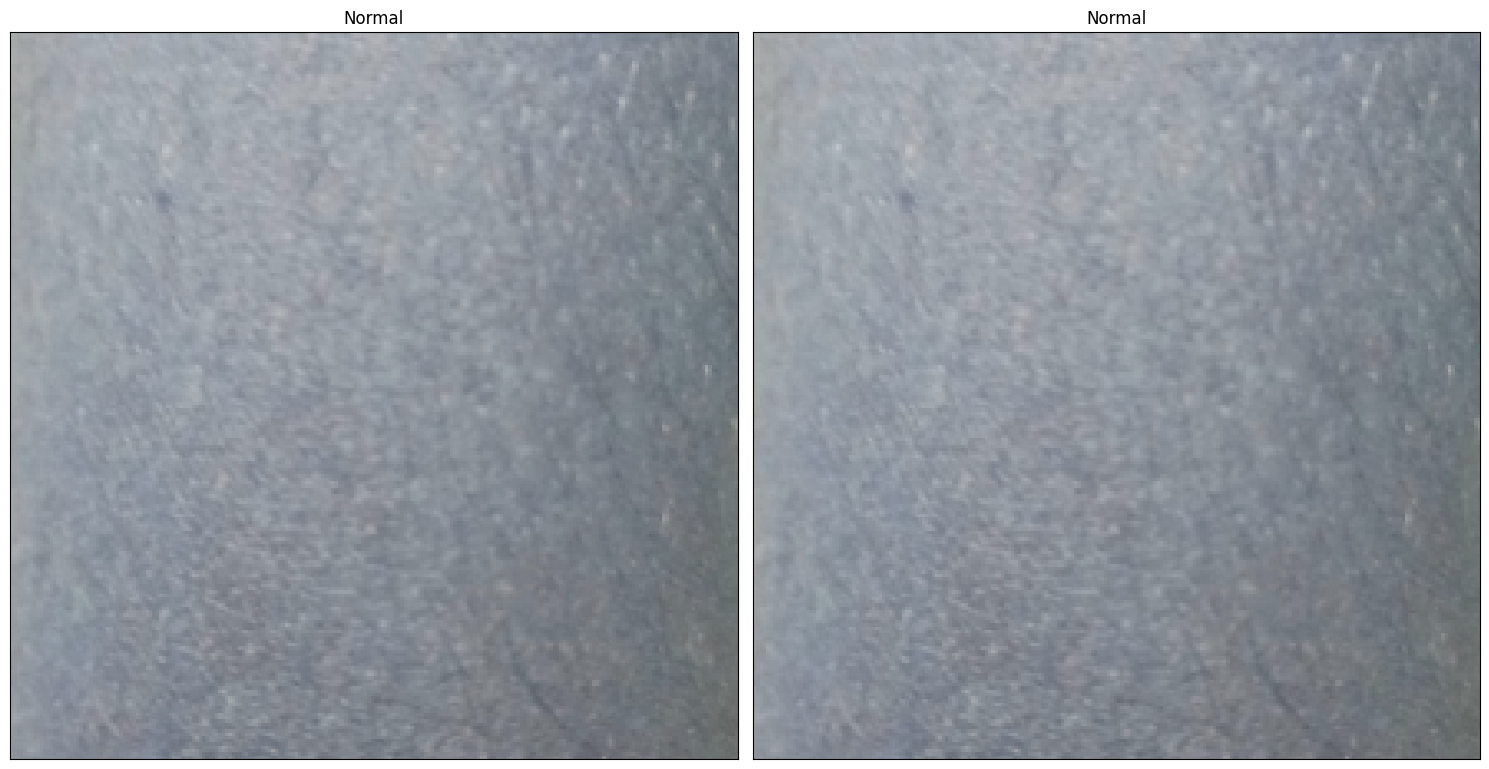

In [30]:
import cv2
Diesease_images = glob.glob(train_path+"/Melanoma/*.jpeg")
normal_images = glob.glob(train_path+"/NotMelanoma/*.jpg")
normalimages = glob.glob(train_path+"/Normal/*.png")
plt.figure(figsize=(15, 10))
plt.pie(x=np.array([len(normal_images), len(Diesease_images), len(normalimages)]), autopct="%.1f%%", explode=[0.2,0,0], labels=["Non-Melanoma", "Melanoma","Normal"], pctdistance=0.5)
plt.title("Type of images and their share in train folder", fontsize=14);
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,10), subplot_kw={'xticks':[], 'yticks':[]})
for i, ax in enumerate(axes.flat):
    img = cv2.imread(Diesease_images[i])
    img = cv2.resize(img, (512,512))
    ax.imshow(img)
    ax.set_title("Melanoma")

plt.show()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,10), subplot_kw={'xticks':[], 'yticks':[]})
for i, ax in enumerate(axes.flat):
    img = cv2.imread(normal_images[i])
    img = cv2.resize(img, (220,220))
    ax.imshow(img)
    ax.set_title("Non-Melanoma")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,10), subplot_kw={'xticks':[], 'yticks':[]})
for i, ax in enumerate(axes.flat):
    img = cv2.imread(normalimages[i])
    img = cv2.resize(img, (220,220))
    ax.imshow(img)
    ax.set_title("Normal")
fig.tight_layout()
plt.show()

### Extracting Features

In [31]:
def extract_features(directory, sample_count,batch_size):
    datagen = ImageDataGenerator(rescale=1./255)
    generator = datagen.flow_from_directory(
    directory,
    batch_size=batch_size,
    target_size=(32,32),
    shuffle=False)
    class_names=generator.class_indices

    image_count = 0
    X_batches, Y_batches = [], []
    for inputs_batch, labels_batch in generator:
        X_batches.append(inputs_batch)
        Y_batches.append(labels_batch)
        image_count += inputs_batch.shape[0]
        # Must interrupt image_generator
        if image_count >= generator.n:

                break
        X = np.concatenate(X_batches)
        Y = np.concatenate(Y_batches)

    return X, Y,class_names

### Train - Test Split

In [40]:
train_features, train_labels,class_names1 = extract_features(train_path,200,32)

Found 11924 images belonging to 3 classes.


In [34]:
test_features, test_labels,c_names2 = extract_features(test_path,100,1)

Found 11924 images belonging to 3 classes.


In [42]:
labels=os.listdir(test_path)
len(test_features)

11923

In [ ]:
train_features.shape[1:]

### Model Training

In [44]:
from keras import optimizers
from keras._tf_keras.keras.models import Sequential
from keras._tf_keras.keras.layers import Activation, Dense, Dropout, Flatten
from keras._tf_keras.keras.utils import to_categorical
from keras._tf_keras.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, classification_report
from keras._tf_keras.keras.layers import Input, Lambda, Dense, Flatten,Conv2D,MaxPool2D
from keras._tf_keras.keras.models import Model
from keras._tf_keras.keras.layers import Conv2D, MaxPooling2D

def model1(shape,n_labels):
    model = Sequential()
    model.add(Flatten(input_shape=shape))
    model.add(Dense(64))
    model.add(Dense(128))
    model.add(Dense(256))
    model.add(Activation('relu'))
    model.add(Dense(n_labels, activation='softmax'))
    return model

In [45]:
model=model1(train_features.shape[1:],len(labels))

In [46]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,787 (932.76 KB)

 Trainable params: 238,787 (932.76 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.compile(optimizer='adam',
loss='binary_crossentropy',
metrics=['acc'])

In [48]:
model.fit(train_features, train_labels, epochs=100, batch_size=32, validation_data=(test_features,test_labels))

Epoch 1/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - acc: 0.6580 - loss: 0.4588 - val_acc: 0.7323 - val_loss: 0.3158
Epoch 2/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.7703 - loss: 0.2852 - val_acc: 0.8085 - val_loss: 0.2418
Epoch 3/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.7977 - loss: 0.2501 - val_acc: 0.8016 - val_loss: 0.2654
Epoch 4/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.8019 - loss: 0.2476 - val_acc: 0.7888 - val_loss: 0.2418
Epoch 5/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.8056 - loss: 0.2475 - val_acc: 0.8281 - val_loss: 0.2254
Epoch 6/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.8098 - loss: 0.2422 - val_acc: 0.8276 - val_loss: 0.2300
Epoch 7/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.8268 - loss: 0.2328 - val_acc: 0.8021 - val_loss: 0.2453
Epoch 8/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.8205 - loss: 0.2300 - val_acc: 0.8371 - val_loss: 0.2190
Epoch 9/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms

In [49]:
history = model.fit(train_features, train_labels,
epochs=100,
batch_size=32,
validation_data=(test_features,test_labels)
)
model.save('Output.h5')

Epoch 1/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - acc: 0.9366 - loss: 0.0965 - val_acc: 0.9301 - val_loss: 0.0975
Epoch 2/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.9170 - loss: 0.1236 - val_acc: 0.9438 - val_loss: 0.0892
Epoch 3/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.9368 - loss: 0.0937 - val_acc: 0.9277 - val_loss: 0.0968
Epoch 4/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9300 - loss: 0.1013 - val_acc: 0.9378 - val_loss: 0.0916
Epoch 5/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9306 - loss: 0.1053 - val_acc: 0.9249 - val_loss: 0.1090
Epoch 6/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9337 - loss: 0.0990 - val_acc: 0.9431 - val_loss: 0.0824
Epoch 7/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - acc: 0.9370 - loss: 0.0977 - val_acc: 0.8786 - val_loss: 0.1601
Epoch 8/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9224 - loss: 0.1141 - val_acc: 0.9503 - val_loss: 0.0797
Epoch 9/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/

In [50]:
p=model.predict(test_features)

373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [51]:
p

array([[1.0000000e+00, 1.2200397e-22, 5.6005785e-15],
       [9.9999881e-01, 2.4174626e-10, 1.1553188e-06],
       [1.0000000e+00, 2.1492415e-40, 1.5079749e-28],
       ...,
       [7.0119807e-03, 1.1114918e-07, 9.9298793e-01],
       [1.1733733e-02, 2.4616349e-04, 9.8802012e-01],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00]], dtype=float32)

In [52]:
p = (p > 0.5)
print(classification_report(test_labels,p))

              precision    recall  f1-score   support

           0       0.94      0.93      0.93      3562
           1       1.00      1.00      1.00      4800
           2       0.93      0.94      0.93      3561

   micro avg       0.96      0.96      0.96     11923
   macro avg       0.96      0.96      0.96     11923
weighted avg       0.96      0.96      0.96     11923
 samples avg       0.96      0.96      0.96     11923



In [53]:
from sklearn.metrics import accuracy_score
DLNN = accuracy_score(test_labels, p)
print("Accuracy:",accuracy_score(test_labels, p))

Accuracy: 0.9602449048058375


In [54]:
pre=np.argmax(p,axis=1)
pre

array([0, 0, 0, ..., 2, 2, 2])

In [55]:
r=np.argmax(test_labels,axis=1)
r

array([0, 0, 0, ..., 2, 2, 2])

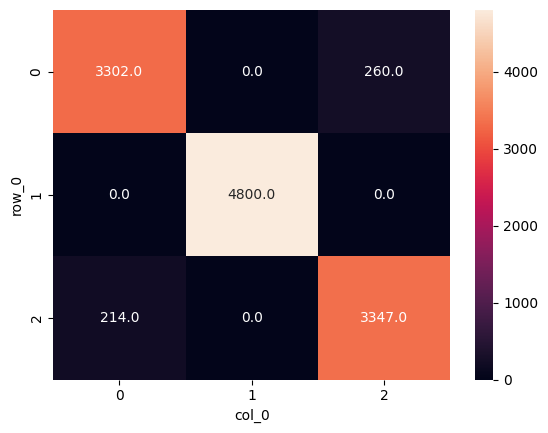

In [56]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sn
y_predict=np.reshape(pre,-1)
confusion_matrix = pd.crosstab(r,y_predict)
confusion_matrix
sn.heatmap(confusion_matrix, annot=True, fmt=".1f")
plt.show()

In [57]:
FP = confusion_matrix.sum(axis=0) - np.diag(confusion_matrix)
FN = confusion_matrix.sum(axis=1) - np.diag(confusion_matrix)
TP = np.diag(confusion_matrix)
TN = confusion_matrix.values.sum() - (FP + FN + TP)

# Sensitivity, hit rate, recall, or true positive rate
TPR = TP/(TP+FN)
# Specificity or true negative rate
TNR = TN/(TN+FP)

# Negative predictive value
NPV = TN/(TN+FN)
# Fall out or false positive rate
FPR = FP/(FP+TN)
# False negative rate
FNR = FN/(TP+FN)
# False discovery rate
FDR = FP/(TP+FP)

# Overall accuracy
ACC = (TP+TN)/(TP+FP+FN+TN)
print('False postive value : ',FP)
print('False Negative value : ',FN)
print('True postive value : ',TP)
print('True Negative value : ',FP)

False postive value :  col_0
0    214
1      0
2    260
dtype: int64
False Negative value :  row_0
0    260
1      0
2    214
dtype: int64
True postive value :  [3302 4800 3347]
True Negative value :  col_0
0    214
1      0
2    260
dtype: int64


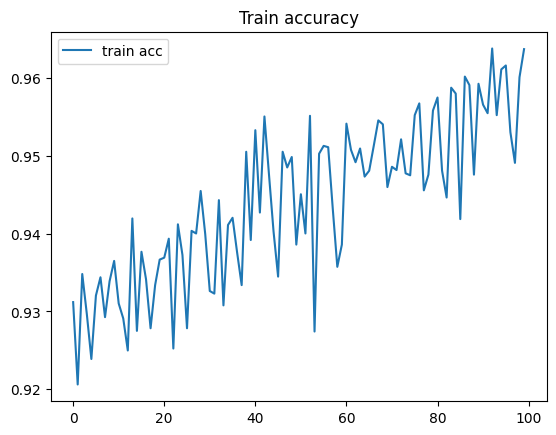

In [58]:
# plot the accuracy
plt.plot(history.history['acc'], label='train acc')
plt.legend()
plt.title("Train accuracy")
plt.show()

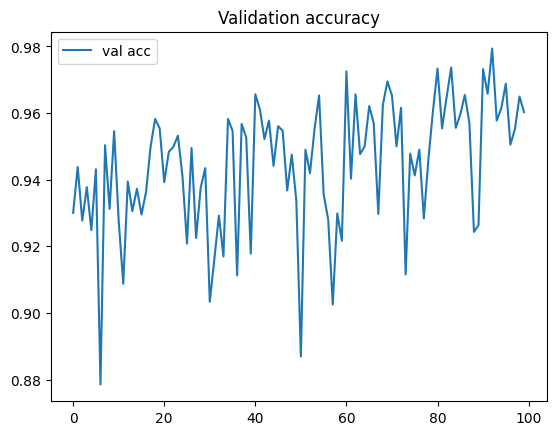

In [59]:
plt.plot(history.history['val_acc'], label='val acc')
plt.legend()
plt.title("Validation accuracy")
plt.show()

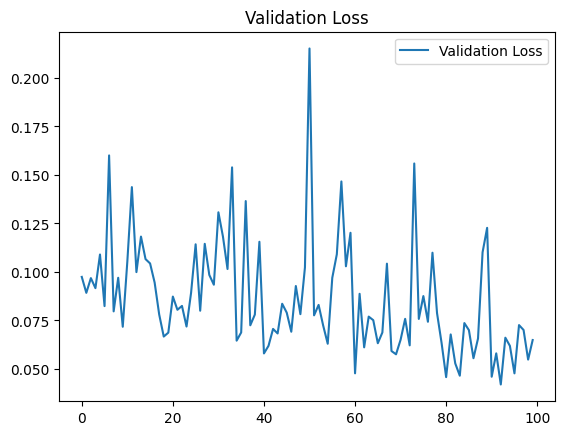

In [60]:
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Validation Loss')
plt.show()

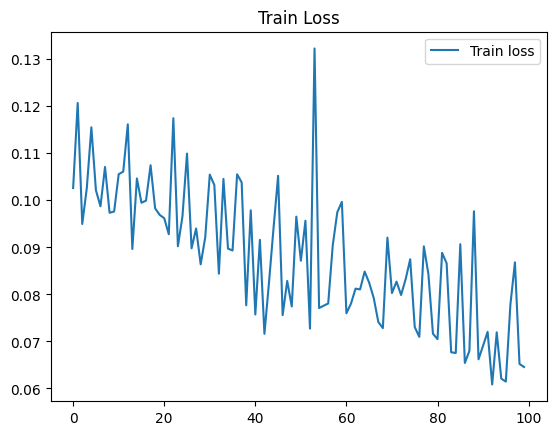

In [61]:
plt.plot(history.history['loss'], label='Train loss')
plt.legend()
plt.title('Train Loss')
plt.show()

In [62]:
from sklearn.metrics import precision_score

In [63]:
# calculate precision
precision = precision_score(r, pre, average='micro')
print('Precision of DLNN: %.3f' % precision)

Precision of DLNN: 0.960


In [64]:
from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(r, pre)

In [65]:
#sensitivity
sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity of DLNN: ', sensitivity1 )

Sensitivity of DLNN:  1.0


In [66]:
#specificity
specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity of DLNN: ', specificity1)

Specificity of DLNN:  1.0


In [67]:
print(classification_report(pre,r))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      3516
           1       1.00      1.00      1.00      4800
           2       0.94      0.93      0.93      3607

    accuracy                           0.96     11923
   macro avg       0.96      0.96      0.96     11923
weighted avg       0.96      0.96      0.96     11923



### DermNet: Blending Neural Network with XGBoost

In [68]:
from keras._tf_keras.keras.models import Model

# Extract features using the trained Neural Network
feature_extractor = Sequential(model.layers[:-1])  # Remove the output layer
features_train = feature_extractor.predict(train_features)
features_test = feature_extractor.predict(test_features)

print("Train features shape:", train_features.shape)
print("Test features shape:", test_features.shape)

372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
373/373 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Train features shape: (11904, 32, 32, 3)
Test features shape: (11923, 32, 32, 3)


**Applying XGB**

In [69]:
import xgboost as xgb

sxg = xgb.XGBClassifier(random_state=10,learning_rate=0.01)

sxg.fit(features_train,np.argmax(train_labels,axis=1))

print('fitting done !!!')

fitting done !!!


In [70]:
DNNXG= sxg.score(features_test,np.argmax(test_labels,axis=1))
print("DermXNet Accuracy: ", DNNXG)

DermXNet Accuracy:  0.957896502558081


In [71]:
y_predict=sxg.predict(features_test)

In [72]:
ss=test_labels

In [73]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sn
#y_predict=np.reshape(pre,-1)
confusion_matrix = pd.crosstab(r,y_predict)
#confusion_matrix
#sn.heatmap(confusion_matrix, annot=True, fmt=".1f")
#plt.show()

In [74]:
FP = confusion_matrix.sum(axis=0) - np.diag(confusion_matrix)
FN = confusion_matrix.sum(axis=1) - np.diag(confusion_matrix)
TP = np.diag(confusion_matrix)
TN = confusion_matrix.values.sum() - (FP + FN + TP)

# Sensitivity, hit rate, recall, or true positive rate
TPR = TP/(TP+FN)
# Specificity or true negative rate
TNR = TN/(TN+FP)

# Negative predictive value
NPV = TN/(TN+FN)
# Fall out or false positive rate
FPR = FP/(FP+TN)
# False negative rate
FNR = FN/(TP+FN)
# False discovery rate
FDR = FP/(TP+FP)

# Overall accuracy
ACC = (TP+TN)/(TP+FP+FN+TN)
print('False postive value : ',FP)
print('False Negative value : ',FN)
print('True postive value : ',TP)
print('True Negative value : ',FP)

False postive value :  col_0
0    156
1      2
2    344
dtype: int64
False Negative value :  row_0
0    344
1      0
2    158
dtype: int64
True postive value :  [3218 4800 3403]
True Negative value :  col_0
0    156
1      2
2    344
dtype: int64


In [75]:
from sklearn.metrics import precision_score

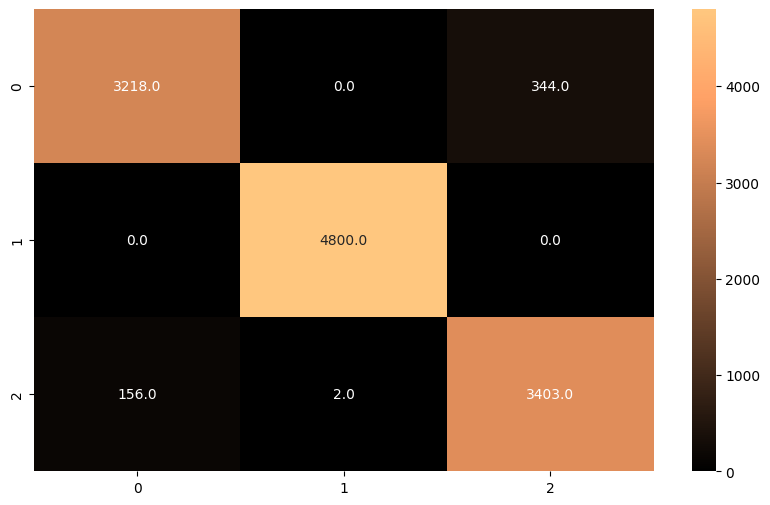

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(r, y_predict)

fig = plt.subplots(1, 1,figsize=(10,6))


sns.heatmap(cm, annot=True, cmap=plt.cm.copper, fmt=".1f")
plt.show()

In [77]:
# print classification report
print(classification_report(r, y_predict))

              precision    recall  f1-score   support

           0       0.95      0.90      0.93      3562
           1       1.00      1.00      1.00      4800
           2       0.91      0.96      0.93      3561

    accuracy                           0.96     11923
   macro avg       0.95      0.95      0.95     11923
weighted avg       0.96      0.96      0.96     11923



In [78]:
#sensitivity
sensitivity2 = cm[0,0]/(cm[0,0]+cm[0,1])
print('Sensitivity of DermXNet: ', sensitivity2 )

Sensitivity of DermXNet:  1.0


In [79]:
# calculate precision
precision1 = precision_score(r, y_predict, average='micro')
print('Precision of DermXNet: %.3f' % precision1)

Precision of DermXNet: 0.958


In [80]:
#specificity
specificity2 = cm[1,1]/(cm[1,0]+cm[1,1])
print('Specificity of DermXNet: ', specificity2)

Specificity of DermXNet:  1.0


In [81]:
CNNXG = 0.92
NN = 0.90
NNSVM = 0.94

SCNNXG = 0.91
SNN = 0.85
SNNSVM = 0.92

SPCNNXG = 0.85
SPNN = 0.94
SPNNSVM = 0.96

# Comparison Graph

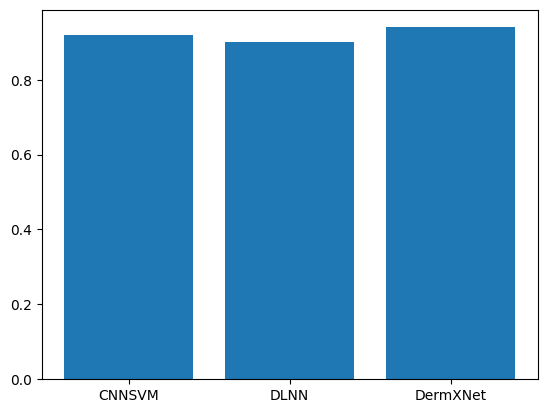

In [82]:
from statistics import mean, stdev
import matplotlib.pyplot as plt
CNNXG=[CNNXG]
NN=[NN]
NNSVM=[NNSVM]
CNNXG_mean = mean(CNNXG)
DLNNSVM_mean = mean(NNSVM)
DLNN_mean = mean(NN)
plt.bar(['CNNSVM','DLNN','DermXNet'],[CNNXG_mean,DLNN_mean,DLNNSVM_mean])
plt.show()

### Specificity

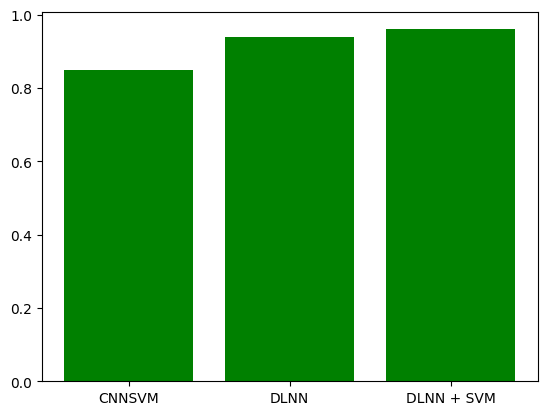

In [83]:
Spec=[SPCNNXG]
Spec1=[SPNN]
Spec2=[SPNNSVM]
Spec_mean = mean(Spec)
Spec1_mean = mean(Spec1)
Spec2_mean = mean(Spec2)
plt.bar(['CNNSVM','DLNN','DLNN + SVM'],[Spec_mean,Spec1_mean,Spec2_mean],color='green')
plt.show()

### Sensitivity

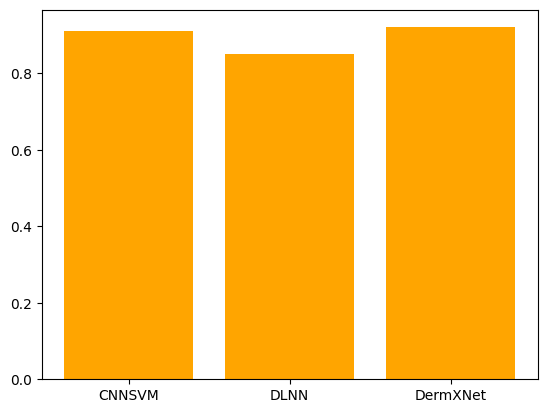

In [84]:
Sec2=[SNNSVM]
Sen=[SCNNXG]
Sen1=[SNN]
Sen_mean = mean(Sen)
Sen1_mean = mean(Sen1)
Sec2_mean = mean(Sec2)
plt.bar(['CNNSVM','DLNN','DermXNet'],[Sen_mean,Sen1_mean,Sec2_mean],color='orange')
plt.show()

# Testing

In [96]:
from keras._tf_keras.keras.models import load_model
import cv2
import numpy as np
model = load_model('Output.h5')
import matplotlib.pyplot as plt

In [97]:
cl=['Melanoma','Normal','NotMelanoma']

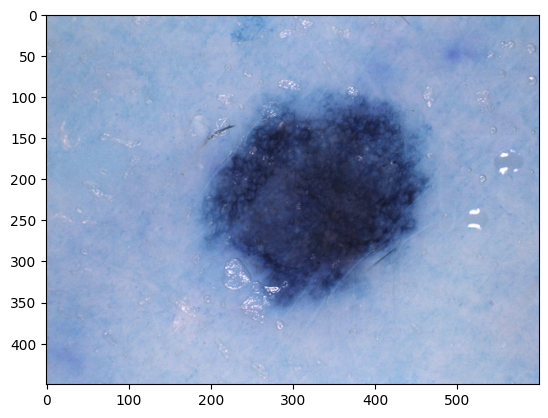

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step


In [115]:
image = cv2.imread('/content/drive/MyDrive/Dataset/NotMelanoma/ISIC_0024319.jpg')
plt.imshow(image)
plt.show()
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image,(32,32))
img4 = np.reshape(image,[1,32,32,3])
#xinput=.predict(image)
cc=model.predict(img4)



In [116]:
g= np.argmax(cc,axis=1)
print("Final Result: ",cl[g[0]])
Ans= cl[g[0]]

Final Result:  NotMelanoma


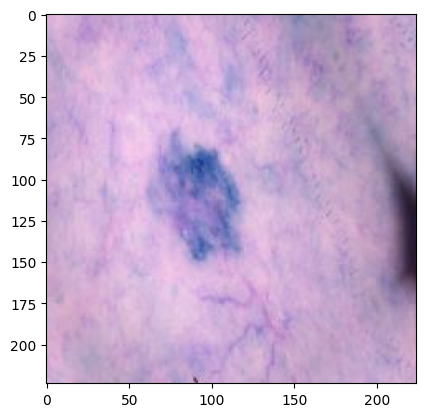

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [119]:
image = cv2.imread('/content/drive/MyDrive/Dataset/Melanoma/AUG_0_28.jpeg')
plt.imshow(image)
plt.show()
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image,(32,32))
img4 = np.reshape(image,[1,32,32,3])
#xinput=.predict(image)
cc=model.predict(img4)

In [120]:
g= np.argmax(cc,axis=1)
print("Final Result: ",cl[g[0]])
Ans= cl[g[0]]

Final Result:  Melanoma
